In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    'Label': [
                'O',
                'B-PERSON',
                'I-PERSON',
                'B-LOCATION',
                'I-LOCATION',
                'B-ORGANIZATION',
                'I-ORGANIZATION',
                'B-SYMPTOM',
                'I-SYMPTOM',
                'B-HISTORY',
                'I-HISTORY',
                'B-ACTION',
                'I-ACTION',
                'B-OTHER',
                'I-OTHER'
             ],
    'Tokens': [
                521782,
                4631,
                1159,
                7515,
                2470,
                1830,
                1521,
                23520,
                12640,
                51430,
                27486,
                21449,
                13282,
                11708,
                7074
              ]
}

dataframe = pd.DataFrame(data)

In [3]:
def extract_entity_type(label):
    """
    Extracts the base class name
    e.g. from B-PERSON to PERSON
    """

    return label.split('-')[-1]


def extract_prefix(label):
    """
    Extracts the BIO prefix
    e.g. B, I or O
    """
    if '-' in label:
        return label.split('-')[0]
    return 'O'

In [4]:
dataframe['Percentage'] = (dataframe['Tokens'] / dataframe['Tokens'].sum()) * 100
dataframe['Type'] = dataframe['Label'].apply(extract_entity_type)
dataframe['Prefix'] = dataframe['Label'].apply(extract_prefix)

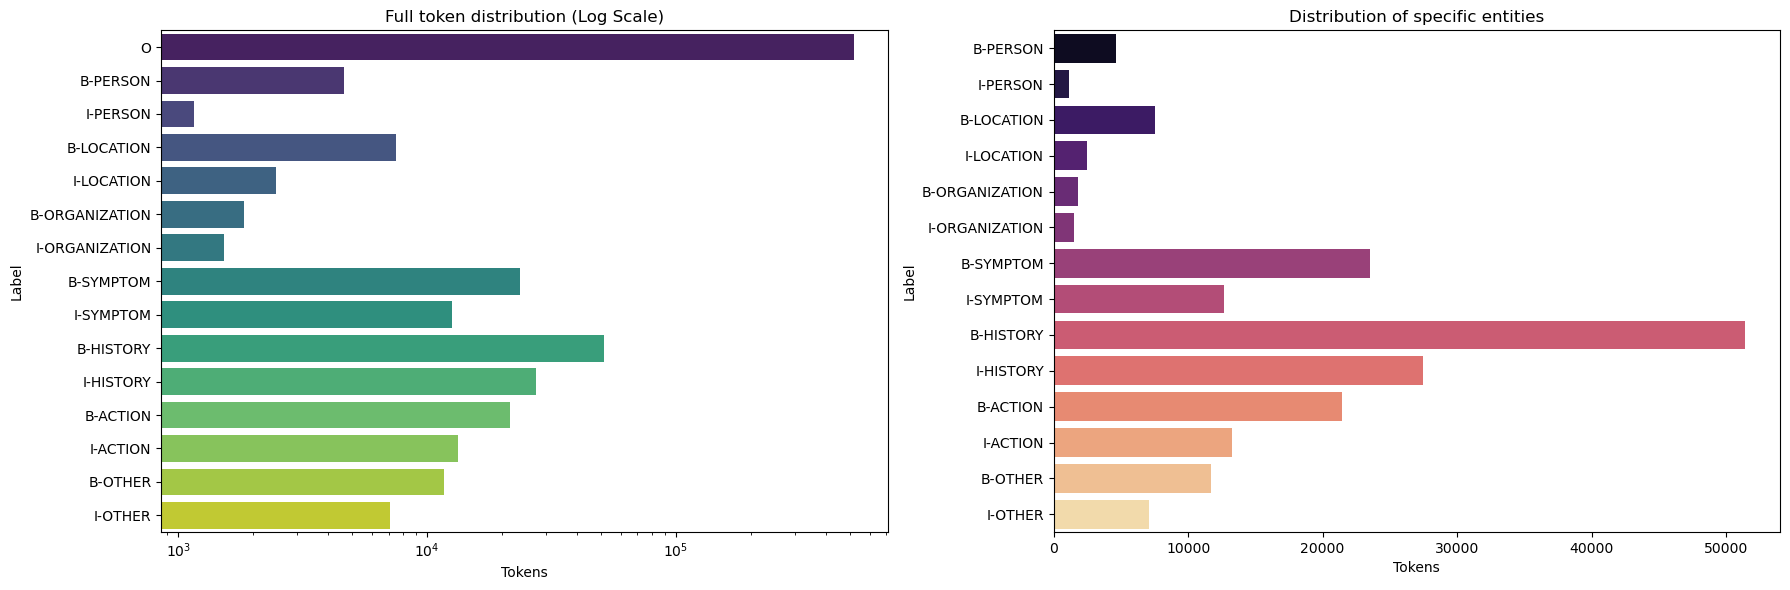

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=dataframe, x='Tokens', y='Label', ax=axes[0], palette='viridis', hue='Label', legend=False)
axes[0].set_title('Full token distribution (Log Scale)')
axes[0].set_xscale('log')

entity_dataframe = dataframe[dataframe['Label'] != 'O'].copy()
sns.barplot(data=entity_dataframe, x='Tokens', y='Label', ax=axes[1], palette='magma', hue='Label', legend=False)
axes[1].set_title('Distribution of specific entities')

plt.tight_layout()
plt.show()

In [14]:
b_counts = dataframe[dataframe['Prefix'] == 'B'][['Type', 'Tokens']].rename(columns={'Tokens': 'B_tokens'})
i_counts = dataframe[dataframe['Prefix'] == 'I'][['Type', 'Tokens']].rename(columns={'Tokens': 'I_tokens'})

stats_dataframe = pd.merge(b_counts, i_counts, on='Type')
stats_dataframe['Average_Tokens_Per_Entity'] = 1 + (stats_dataframe['I_tokens'] / stats_dataframe['B_tokens'])

print(stats_dataframe[['Type', 'Average_Tokens_Per_Entity']].sort_values(by='Average_Tokens_Per_Entity', ascending=False))

           Type  Average_Tokens_Per_Entity
2  ORGANIZATION                   1.831148
5        ACTION                   1.619236
6         OTHER                   1.604202
3       SYMPTOM                   1.537415
4       HISTORY                   1.534435
1      LOCATION                   1.328676
0        PERSON                   1.250270
